In [1]:
# Use elastic net to predict drug sensitivity based on whole transcriptome data

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from functools import reduce
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, roc_auc_score, make_scorer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.svm import SVR, SVC
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.linear_model import ElasticNet

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.pipeline import Pipeline

import random
import logging
import sys
import json
import os
from datetime import datetime
from tqdm import tqdm
from scipy.stats import pearsonr
from scipy import stats

def grid_search_corr(y_true, y_pred):
    return pearsonr(y_true, y_pred)[0]

import warnings
warnings.filterwarnings("ignore")

/home/josh/.local/lib/python3.11/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
dep_dir = '/media/josh/wd/data/depmap/22Q2/'
drug_dir = '~/Documents/Data_Analysis/SSOT/data/depmap'
drug = 'topotecan'
drug = drug.upper()

In [3]:
configs = json.load(open('configs/rna_en_grid_search_ic50.json', 'r'))

In [4]:
configs

{'meta_file': '/home/scai/SangerDrug/data/E0022_P06_final_sample_map_no_control.txt',
 'data_file': '/home/scai/SangerDrug/data/rna/rnaseq_voom.csv',
 'cell_lines_train': '/home/scai/SangerDrug/data/protein/E0022_P06_Protein_Matrix_ProNorM_no_control_train.txt',
 'cell_lines_test': '/home/scai/SangerDrug/data/protein/E0022_P06_Protein_Matrix_ProNorM_no_control_test.txt',
 'ic50_file': '/home/scai/SangerDrug/data/drug/drug_final_processed_eg_id.csv',
 'model': 'en',
 'cv': 5,
 'params_grid': {'alpha': [0.1, 0.5, 1],
  'l1_ratio': [0.2, 0.4, 0.5, 0.6, 0.8],
  'max_iter': [10000]},
 'imputer': 'None',
 'seed': 42,
 'work_dir': '/home/scai/SangerDrug/work_dirs/rna/ElasticNet',
 'min_cell_lines': 300,
 'importance': True,
 'data_type': 'rna',
 'task': 'regression',
 'metric': 'corr',
 'sign': 1,
 'target': 'ln_IC50',
 'suffix': '_rna_300_eg_id'}

In [5]:
seed = configs['seed']
cv = KFold(n_splits=configs['cv'], shuffle=True, random_state=seed)


In [6]:
cv

KFold(n_splits=5, random_state=42, shuffle=True)

In [7]:
corr_score = make_scorer(grid_search_corr, greater_is_better=True)

In [8]:
if configs['task'].lower() == 'classification':
    model_dict = {'rf': RandomForestClassifier(),
                  'svm': SVC(),
                  'en': ElasticNet(),
                  'svm-linear': SVC(kernel='linear'),
                  'mlp': MLPClassifier()}

else:
    model_dict = {'rf': RandomForestRegressor(),
                  'svm': SVR(),
                  'en': ElasticNet(),
                  'svm-linear': SVR(kernel='linear'),
                  'mlp': MLPRegressor()}


In [9]:
reg = model_dict[configs['model']]
param_grid = configs['params_grid']

In [10]:
LIN = pd.read_csv(f'{dep_dir}/sample_info.csv')
LIN.head(3)

,DepMap_ID,cell_line_name,stripped_cell_line_name,CCLE_Name,alias,COSMICID,sex,source,RRID,WTSI_Master_Cell_ID,...,lineage_sub_subtype,lineage_molecular_subtype,default_growth_pattern,model_manipulation,model_manipulation_details,patient_id,parent_depmap_id,Cellosaurus_NCIt_disease,Cellosaurus_NCIt_id,Cellosaurus_issues
0,ACH-000016,SLR 21,SLR21,SLR21_KIDNEY,NaN,NaN,NaN,Academic lab,CVCL_V607,NaN,...,NaN,NaN,NaN,NaN,NaN,PT-JnARLB,NaN,Clear cell renal cell carcinoma,C4033,NaN
1,ACH-000032,MHH-CALL-3,MHHCALL3,MHHCALL3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,NaN,Female,DSMZ,CVCL_0089,NaN,...,b_cell,NaN,NaN,NaN,NaN,PT-p2KOyI,NaN,Childhood B acute lymphoblastic leukemia,C9140,NaN
2,ACH-000033,NCI-H1819,NCIH1819,NCIH1819_LUNG,NaN,NaN,Female,Academic lab,CVCL_1497,NaN,...,NSCLC_adenocarcinoma,NaN,NaN,NaN,NaN,PT-9p1WQv,NaN,Lung adenocarcinoma,C3512,NaN


In [11]:
name_map = LIN[['CCLE_Name', 'DepMap_ID']]
name_map = name_map.rename({'CCLE_Name': 'ccle_name', 'DepMap_ID': 'broad_id'}, axis = 1)
name_map.head(3)

,ccle_name,broad_id
0,SLR21_KIDNEY,ACH-000016
1,MHHCALL3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,ACH-000032
2,NCIH1819_LUNG,ACH-000033


In [12]:
# drug_sensitivity = pd.read_csv(f'{dep_dir}/drug_sensitivity_IC50_GDSC_ccle.csv', index_col = 0)
drug_sensitivity = pd.read_csv(f'{drug_dir}/sanger-dose-response.csv')
drug_sensitivity.head(3)

,DATASET,COSMIC_ID,DRUG_ID,MIN_CONC,MAX_CONC,RMSE_PUBLISHED,Z_SCORE_PUBLISHED,IC50_PUBLISHED,AUC_PUBLISHED,ARXSPAN_ID,DRUG_NAME,BROAD_ID,upper_limit,ec50,slope,lower_limit,auc,log2.ic50,mse,R2
0,GDSC1,683665,1,0.007813,2.0,0.022518,-0.192056,10.977393,0.982116,ACH-002270,ERLOTINIB,BRD-K70401845,0.992788,2.839376,-5.670993,0.514389,0.990834,NaN,0.000034,0.904675
1,GDSC1,684055,1,0.007813,2.0,0.031831,0.505823,23.133991,0.984820,ACH-002104,ERLOTINIB,BRD-K70401845,1.006405,0.028649,-0.186377,0.990054,0.997138,NaN,0.000057,0.028903
2,GDSC1,684057,1,0.007813,2.0,0.026047,1.280750,52.935278,0.985696,ACH-002106,ERLOTINIB,BRD-K70401845,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
drug_dat = drug_sensitivity[['ARXSPAN_ID', 'IC50_PUBLISHED', 'DRUG_NAME']]
drug_dat = drug_dat[drug_dat['DRUG_NAME'] == drug]
drug_dat['log2ic50'] = np.log2(drug_dat['IC50_PUBLISHED'])
drug_dat = drug_dat.drop(['IC50_PUBLISHED'], axis = 1)
drug_dat.head(3)

,ARXSPAN_ID,DRUG_NAME,log2ic50
340525,ACH-000958,TOPOTECAN,0.667914
340526,ACH-000566,TOPOTECAN,2.574963
340527,ACH-000651,TOPOTECAN,-0.583088


<Axes: xlabel='log2ic50', ylabel='Count'>

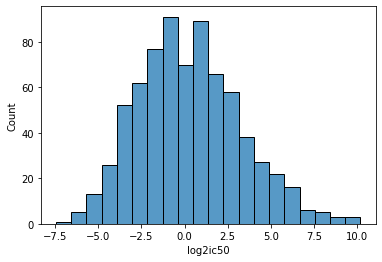

In [14]:
sns.histplot(drug_dat['log2ic50'])

In [15]:
drug_df = pd.merge(drug_dat, name_map, left_on = 'ARXSPAN_ID', right_on = 'broad_id', how = 'inner') 
drug_df.index = drug_df['ccle_name']
drug_df = drug_df.drop(['ccle_name', 'broad_id'], axis = 1)
drug_df.shape

(712, 3)

In [16]:
drug_df.head(3)

,ARXSPAN_ID,DRUG_NAME,log2ic50
ccle_name,,,
SW48_LARGE_INTESTINE,ACH-000958,TOPOTECAN,0.667914
SW1710_URINARY_TRACT,ACH-000566,TOPOTECAN,2.574963
SW620_LARGE_INTESTINE,ACH-000651,TOPOTECAN,-0.583088


In [17]:
drug_df = drug_df[drug_df['log2ic50'].notna()]
drug_df.shape

(712, 3)

In [18]:
x_ccle = pd.read_csv(f'{dep_dir}/x-ccle.csv', index_col = 0) 
x_ccle.iloc[1:3, 1:6]

,GE_TNMD,GE_DPM1,GE_SCYL3,GE_C1orf112,GE_FGR
RT4_URINARY_TRACT,0.0,6.537607,2.456806,3.867896,0.799087
SNU1196_BILIARY_TRACT,0.0,6.533875,2.226509,3.021480,0.028569


In [19]:
rna_columns = [c for c in x_ccle.columns.tolist() if 'GE_' in c]
x_exp = x_ccle.loc[:, rna_columns]
x_exp.columns = x_exp.columns.str.replace('GE_', '')
x_exp.head(2)

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,H3C2,H3C3,AC098582.1,DUS4L.BCAP29,C8orf44.SGK3,ELOA3B,NPBWR1,ELOA3D,ELOA3,CDR1
LC1SQSF_LUNG,4.331992,0.0,7.364397,2.792855,4.470537,0.028569,1.226509,3.042644,6.499686,4.739848,...,2.689299,0.189034,0.201634,2.130931,0.555816,0.0,0.275007,0.0,0.0,0.0
RT4_URINARY_TRACT,6.729145,0.0,6.537607,2.456806,3.867896,0.799087,7.208381,5.569856,7.127014,4.568032,...,1.117695,2.358959,0.084064,1.910733,0.000000,0.0,0.464668,0.0,0.0,0.0


In [20]:
common_cells = list(set(drug_df.index.tolist()).intersection(x_exp.index.tolist()))

In [21]:
train_cells = random.sample(common_cells, int(len(common_cells) * 0.8))
test_cells = list(set(common_cells) - set(train_cells))

In [22]:
y_train = drug_df.loc[train_cells, 'log2ic50']
X_train = x_exp.loc[train_cells, :]

In [23]:
X_train.iloc[1:3, 1:6]

,TNMD,DPM1,SCYL3,C1orf112,FGR
MDAMB361_BREAST,0.0,6.736740,2.885574,3.766595,0.028569
YAPC_PANCREAS,0.0,6.796105,3.039138,3.710393,0.214125


In [24]:
gene_list = X_train.columns.tolist()
correlation_df = []
for g in gene_list:
    
    coef,p= stats.spearmanr(X_train[g],y_train)
    res = pd.DataFrame({'gene' : [g], 'Rho': [coef], 'pVale':[p]})
    correlation_df.append(res)
correlation_df = pd.concat(correlation_df)

In [25]:
top_corr = correlation_df.sort_values('pVale').head(500)
top_corr_genes = top_corr['gene'].tolist()

In [26]:
top_corr.head()

,gene,Rho,pVale
0,SLFN11,-0.408122,8.126016e-12
0,FLVCR2,0.350794,6.487998e-09
0,KATNB1,-0.316531,1.951942e-07
0,AGPAT5,-0.314760,2.301615e-07
0,F10,0.308087,4.241841e-07


In [27]:
X_train = X_train.loc[:, top_corr_genes]
X_train.shape

(259, 500)

In [28]:
y_test = drug_df.loc[test_cells, 'log2ic50']
X_test = x_exp.loc[test_cells, top_corr_genes]
X_test.shape


(65, 500)

In [29]:
# X_train = pd.DataFrame(scaler.fit_transform(X_train))
# X_test = pd.DataFrame(scaler.fit(X_test))

# scaler = StandardScaler().fit(X_train)
# train_sc = scaler.transform(X_train)

# test_sc = scaler.transform(X_test)

In [30]:
modelpipeline = Pipeline(steps=[('scaler', StandardScaler()), ('model', reg)])

# param_grid = {'model__alpha': [0.1, 0.5, 1], 
#               'model__l1_ratio': [0.2, 0.4, 0.5, 0.6, 0.8],
#               'model__max_iter': [10000]}

# param_grid = {'model__alpha': [0.05, 0.1, 0.25, 0.4, 0.5, 0.75, 0.85, 1], 
#               'model__l1_ratio': [0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9],
#               'model__max_iter': [10000]}

# param_grid = {'model__alpha': [0.05, 0.1, 0.25, 0.4, 0.5, 0.75, 0.85, 1], 
#               'model__l1_ratio': [0.2, 0.4, 0.5, 0.6, 0.8],
#               'model__max_iter': [10000]}

# param_grid = {'model__alpha': [0.1, 0.3, 0.5, 0.75, 1], 
#               'model__l1_ratio': [0.2, 0.4, 0.5, 0.6, 0.8],
#               'model__max_iter': [10000]}

# param_grid = {'model__alpha': [0.1, 0.3, 0.5,  1], 
#               'model__l1_ratio': [0.2, 0.4, 0.5, 0.6, 0.8],
#               'model__max_iter': [10000]}

# param_grid = {'model__alpha': [0.4], 
#               'model__l1_ratio': [0.10],
#               'model__max_iter': [10000]}

param_grid = {'model__alpha': [0.1, 0.5, 1], 
              'model__l1_ratio': [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8],
              'model__max_iter': [10000]}



In [31]:
#     rcv = GridSearchCV(reg, param_grid, n_jobs=100, cv=cv, scoring=corr_score, refit=True)
    
#     rcv = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('model', reg)]), param_grid, n_jobs=100, cv=cv, scoring=corr_score, refit=True)
# run grid search
if configs['metric'] == 'corr':
    rcv = GridSearchCV(modelpipeline, param_grid, n_jobs=100, cv=cv, scoring=corr_score, refit=True)
#     rcv = GridSearchCV(reg, param_grid, n_jobs=100, cv=cv, scoring=corr_score, refit=True)
else:
    rcv = GridSearchCV(reg, param_grid, n_jobs=100, cv=cv, scoring=configs['metric'], refit=True)
    
if configs['imputer'].lower() == 'none':
    rcv.fit(X_train, y_train)
    y_pred = rcv.best_estimator_.predict(X_test)
else:
    rcv.fit(imputer.fit_transform(X_train), y_train)
    y_pred = rcv.best_estimator_.predict(imputer.transform(X_test))

/home/josh/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.282e+00, tolerance: 1.585e-01
  model = cd_fast.enet_coordinate_descent(


In [32]:
# gather results
if 'sign' in configs:
    sign = configs['sign']
else:
    sign = -1 if configs['task'] == 'regression' else 1

if configs['task'].lower() == 'classification':
    test_auc = roc_auc_score(y_test, y_pred)
    score_dict = {'drug_id': drug, 'val_mae': sign * rcv.best_score_, 'test_score': test_auc}
else:
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = mean_squared_error(y_test, y_pred, squared=False)
    test_r2 = r2_score(y_test, y_pred)
    test_corr = pearsonr(y_test, y_pred)[0]
    score_dict = {'drug_id': drug, 'val_score': sign * rcv.best_score_,
                  'test_mae': test_mae, 'test_rmse': test_rmse,
                  'test_r2': test_r2, 'test_corr': test_corr}

In [33]:
for i in range(configs['cv']):
    score_dict[f"cv{i}_{configs['metric']}"] = sign * rcv.cv_results_[f'split{i}_test_score'][rcv.best_index_]


In [34]:
# record best params
params = rcv.best_params_
params['drug_id'] = drug



# record feature importance if possible
importances = None
if configs["importance"]:
    if configs['model'] in ('rf', 'lgbm'):
        importances = rcv.best_estimator_.feature_importances_
    elif configs['model'] in ('svm-linear'):
        importances = rcv.best_estimator_.coef_[0]
    elif configs['model'] in ('en'):
#         importances = rcv.best_estimator_.coef_
        importances = rcv.best_estimator_.named_steps['model'].coef_
    else:
        logger.error("feature importance is not supported for the current model.")


In [35]:
df_importance = pd.DataFrame({'Genes': X_train.columns, 'Coefficients': importances})
df_importance = df_importance[df_importance['Coefficients'] != 0].sort_values('Coefficients', ascending = False)
df_importance

,Genes,Coefficients
148,MTRNR2L7,0.168470
383,TMBIM4,0.122290
326,RGS9BP,0.108858
390,ASAP2,0.100319
4,F10,0.098958
...,...,...
216,GLYATL2,-0.113645
496,FHAD1,-0.115890
164,LTA4H,-0.127773
391,SLC38A5,-0.137730


In [36]:
df_importance.tail(10)

,Genes,Coefficients
392,PGAM4,-0.083343
215,CCDC28A,-0.083545
465,BTN3A2,-0.089888
448,CLEC2B,-0.098427
205,AIM2,-0.098929
216,GLYATL2,-0.113645
496,FHAD1,-0.115890
164,LTA4H,-0.127773
391,SLC38A5,-0.137730
0,SLFN11,-0.271678


In [37]:
params
# best paramters
# {'model__alpha': 0.1,
#  'model__l1_ratio': 0.6,
#  'model__max_iter': 10000,
#  'drug_id': 'topotecan'}

# {'model__alpha': 1,
#  'model__l1_ratio': 0.05,
#  'model__max_iter': 10000,
#  'drug_id': 'TOPOTECAN'}

{'model__alpha': 1,
 'model__l1_ratio': 0.05,
 'model__max_iter': 10000,
 'drug_id': 'TOPOTECAN'}

In [38]:
score_dict

{'drug_id': 'TOPOTECAN',
 'val_score': 0.6100533951154489,
 'test_mae': 2.159954969204849,
 'test_rmse': 2.654538933780142,
 'test_r2': 0.22160839191132953,
 'test_corr': 0.47652537747662616,
 'cv0_corr': 0.6257496928083284,
 'cv1_corr': 0.5059176568383117,
 'cv2_corr': 0.5696043173103819,
 'cv3_corr': 0.7261703340389709,
 'cv4_corr': 0.6228249745812517}

In [39]:
pearsonr(y_test, y_pred)[0]

0.47652537747662616

In [40]:
# plot_df = df_importance[abs(df_importance['Coefficients']) > 0.03]
plot_df = df_importance[abs(df_importance['Coefficients']) > 0.08]
plot_df.shape

(23, 2)

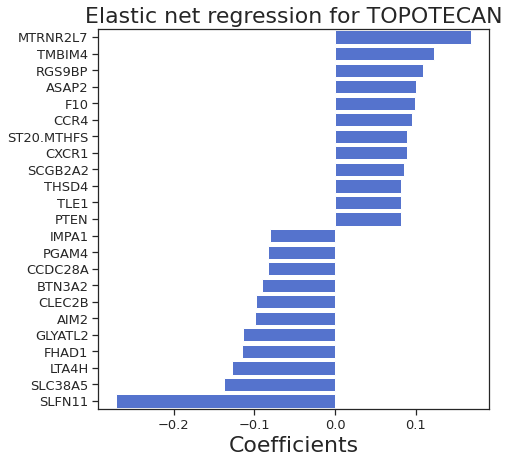

In [41]:
plt.figure(figsize = (7, 7))
sns.set_theme(style = 'ticks')
ax = sns.barplot(
    data= plot_df,
    x= 'Coefficients',
    y= 'Genes', palette = ['royalblue'])

ax.axes.set_title(f"Elastic net regression for {drug}",fontsize=22)
ax.set_xlabel("Coefficients",fontsize=22)
ax.set_ylabel("",fontsize=22)
ax.tick_params(labelsize=13)

In [42]:
drug_df.head(2)

,ARXSPAN_ID,DRUG_NAME,log2ic50
ccle_name,,,
SW48_LARGE_INTESTINE,ACH-000958,TOPOTECAN,0.667914
SW1710_URINARY_TRACT,ACH-000566,TOPOTECAN,2.574963


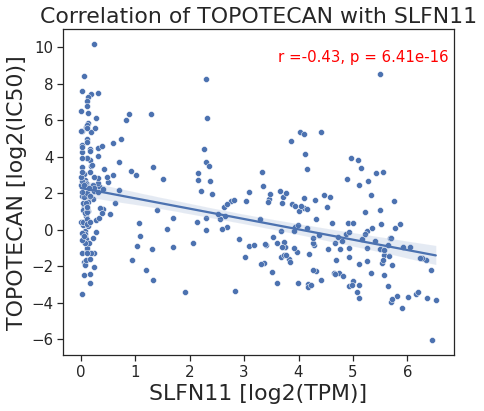

In [43]:
g = plot_df['Genes'].tolist()[-1]
exp_df = x_exp[[g]]
scatter_df = pd.merge(exp_df, drug_df, left_index = True, right_index = True)
r, p = stats.spearmanr(scatter_df[g], scatter_df['log2ic50'])

plt.figure(figsize = (7, 6))
ax = sns.scatterplot(data = scatter_df, x = g, y = 'log2ic50')
sns.regplot(data = scatter_df, x = g, y = 'log2ic50', scatter=False, ax=ax)

plt.text(.55, .9, "r ={:.2f}, p = {:.2e}".format(r, p), 
         transform=ax.transAxes, fontsize=15, color = 'red')

ax.axes.set_title(f"Correlation of {drug} with {g}",fontsize=22)
ax.set_xlabel(f"{g} [log2(TPM)]",fontsize=22)
ax.set_ylabel(f"{drug} [log2(IC50)]",fontsize=22)
ax.tick_params(labelsize=15)